# RFM Analysis on E-commerce dataset

<div style="background-color: #f0f7ff; border-left: 5px solid #5C9AFF; padding: 15px; border-radius: 5px; font-family: 'Roboto', sans-serif;">
    <p style="margin: 0; color: #002047;"><strong>Dataset:</strong> E-commerce dataset</p>
    <p style="margin: 5px 0; color: #002047;"><strong>Source:</strong> <a href="https://www.kaggle.com/datasets/carrie1/ecommerce-data" style="color: #5C9AFF;">Kaggle</a></p>
    <p style="margin: 0; color: #002047;"><strong>Author:</strong> Fishchenko Tamara</p>
</div>


### Styling headers and markdown cells
To improve the document's visual structure and readability, I chose Roboto as my main font, as well as a monochromatic blue gradient to headers.

In [332]:
%%html
<style>
@import url('https://fonts.googleapis.com');
.jp-RenderedHTMLCommon, .text_cell_render { 
    font-family: 'Roboto', sans-serif !important; 
    font-size: 15px !important;
    line-height: 1.6 !important;
}

.jp-RenderedHTMLCommon h1, .jp-RenderedHTMLCommon h2, 
.jp-RenderedHTMLCommon h3, .jp-RenderedHTMLCommon h4 {
    padding: 15px !important;
    border-radius: 8px !important;
    margin-top: 25px !important;
    margin-bottom: 10px !important;
    font-weight: 700 !important;
}

/* # Header 1 */
.jp-RenderedHTMLCommon h1 {
    background-color: #f0f7ff !important;
    border-left: 10px solid #5C9AFF !important;
    color: #002047 !important;
}

/* ## Header 2 */
.jp-RenderedHTMLCommon h2 {
    background-color: #e1ecf7 !important;
    border-left: 10px solid #528ae5 !important;
    color: #003366 !important;
}

/* ### Header 3 */
.jp-RenderedHTMLCommon h3 {
    background-color: #d6e4f2 !important;
    border-left: 10px solid #1e4f9a !important;
    color: #002047 !important;
}

/* #### Header 4 */
.jp-RenderedHTMLCommon h4 {
    background-color: #cbdcf0 !important;
    border-left: 10px solid #002047 !important;
    color: #001530 !important;
}
</style>

### Contents

### Objective

The main goal of this notebook is to perform a full RFM (Recency, Frequency, Monetary) analysis on the dataset, completing the following tasks:
* Constructing RFM metrics for each customer
* Analysing key metrics distributions
* Segmenting customers into groups
* Analysing revenue distribution and purchasing patterns
* Finding appropriate marketing recommendations for each segment

### Expected result

The expected result of this notebook is a segmented customer base with RFM scores, analysed behaviours and formed marketing suggestions.

## Data preparation and loading

In [337]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from IPython.display import display, HTML
from matplotlib.ticker import FuncFormatter
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style="whitegrid")
NICE_BLUE = "#69aeff"
DARK_BLUE = "#000d3f"

plt.rcParams['font.family'] = 'DejaVu Sans'

In [338]:
# used parquet not to lose specified data types
df_cleaned = pd.read_parquet("df_cleaned.parquet")

# products and non-products
df_products = df_cleaned.loc[~df_cleaned["IsNonProduct"]].copy()
df_non_products = df_cleaned.loc[df_cleaned["IsNonProduct"]].copy()

## RFM analysis

Palmatier et al. (2022, Chapter 7) states, "The underlying idea of RFM analysis is that customers who have (1) purchased more recently, (2) made more purchases during a given time period; and (3) spent more on those purchases are more likely to respond to a new offer." From this we can conclude that RFM (Recency, Frequency and Monetary) analysis's purpose is to identify and evaluate the value of customers based on their purchasing behaviour using three key metrics:
* __Recency (R)__: How recently a customer made a purchase. It calculates the time difference between a customer’s most recent transaction and the reference date. Customers with lower recency are considered more valuable because they have interacted with the business recently and are more likely to respond to future marketing campaigns.
* __Frequency (F)__: How often a customer makes a purchase. Customers with high frequency values are considered loyal customers because they repeatedly return to purchase products or services. Moreover, retaining such consumers is usually cheaper than acquiring new ones.
* __Monetary (M)__: How much money a customer spends. Customers with high monetary value generate more revenue and are considered high-value customers.

RFM analysis helps businesses better understand customer behaviour and allocate marketing resources more efficiently by focusing on high-value customer groups who are most likely to generate profit and engagement rather than targeting all customers equally.

According to Wei et al. (2010), RFM analysis can be used for:
1. customer segmentation
3. customer lifetime value (CLV) analysis
4. customer retention
5. response prediction
6. profitability analysis
7. personalised marketing strategies

The same paper highlights that RFM is extremely popular among businesses, including banking, telecommunications, retail and e-commerce, because it is cost-effective, fast for development and relies on already existing data while using a few variables to provide powerful insights. Therefore, it reduces the necessity of using more complex predictive models for primary statistical analysis.

In [341]:
# making dataset for RFM
rfm_df = df_products[
    (df_products["CustomerID"].notna()) &
    (df_products["Quantity"] > 0) &
    (df_products["UnitPrice"] > 0)
].copy()

Negative quantities representing returned or cancelled transactions were removed to focus on understanding completed purchasing behaviour.

The majority of transactions were made in UK and the resulting RFM segments and purchasing patterns will reflect the behaviour of UK's customers and cannot be used for international markets with different consumer behaviours, peak shopping seasons and other external factors.

### Calculating key metrics for each customer

Since the dataset is historical and has dates ranging from December 2010 to December 2011, Recency metric needs to be based within its own timeframe and not the current date. Moreover, adding 1 day ensures that even the most recent buyer gets a recency of at least 1 to prevent issues in scoring or comparisons.

In [344]:
# finding last date in dataset
baseline_date = rfm_df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [345]:
# constructing RFM dataset 
rfm = rfm_df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (baseline_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum")
).reset_index()

#### Metrics distributions

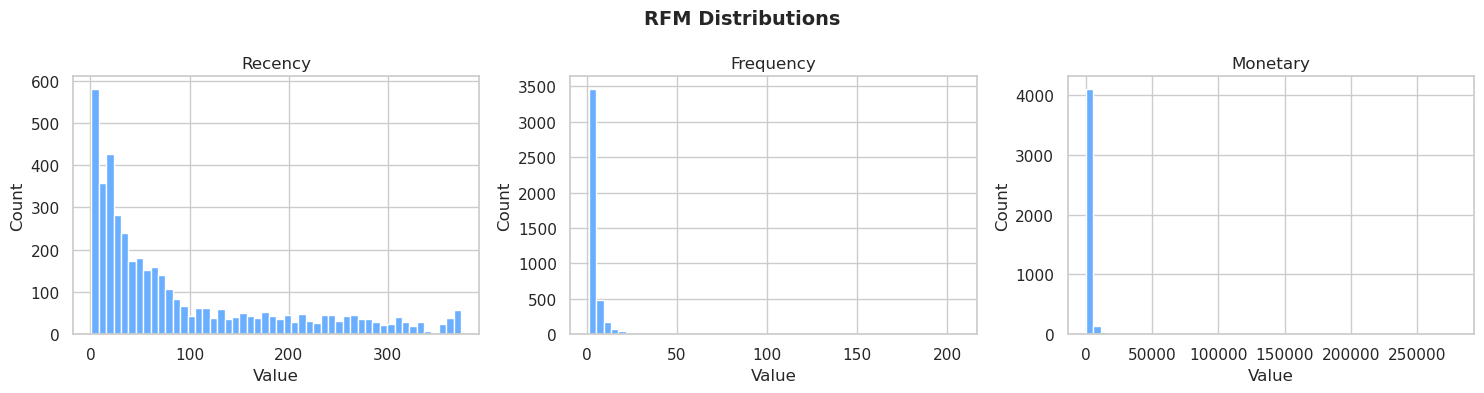

In [346]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# constructing distibutions for metrics
for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    rfm[col].hist(bins=50, ax=ax, color=NICE_BLUE)
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

plt.suptitle("RFM Distributions", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

These histograms show the distribution of RFM metrics with the following results:
1. __Recency__: right-skewed, indicating most customers bought products recently while fewer customers have been inactive for long periods.
3. __Frequency__: heavily right-skewed, where the vast majority of customers made only a few orders (about 1-5) and only a few - larger which is normal for retail datasets.
4. __Monetary__: extremely right-skewed, concentrating near £1000 (meaning many consumers contribute very little to total revenue) with outliers reaching £250,000.

In [348]:
# without log
print("Quantiles boundaries without log:")
print(pd.qcut(rfm["Monetary"], 5).value_counts().sort_index())

# with log
print("\nQuintile boundaries with log:")
print(pd.qcut(np.log1p(rfm["Monetary"]), 5).value_counts().sort_index())

Quantiles boundaries without log:
Monetary
(3.749, 246.81]          867
(246.81, 482.254]        867
(482.254, 922.056]       866
(922.056, 2029.212]      867
(2029.212, 279138.02]    867
Name: count, dtype: int64

Quintile boundaries with log:
Monetary
(1.5570000000000002, 5.513]    867
(5.513, 6.181]                 867
(6.181, 6.828]                 866
(6.828, 7.616]                 867
(7.616, 12.539]                867
Name: count, dtype: int64


As it can be observed, in the case without converting using log, the spending intervals are heavily distorted by extreme values. For instance, the last quintile spans from £2029 to £279,138, boundaries of which represent completely different client types grouped into one segment. Meanwhile, with log transformation the intervals become more balanced.

#### RFM scores construction

In [350]:
# calculating RFM scores
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])
# due to many clients with same number of orders, they need to be ranked for qcut to work properly
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm["M_score"] = pd.qcut(np.log1p(rfm["Monetary"]), 5, labels=[1,2,3,4,5])

# converting RFM scores to numeric type
rfm[["R_score", "F_score", "M_score"]] = rfm[["R_score", "F_score", "M_score"]].astype(int)

# constructing RFM score
rfm["RFM_score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
0,12346.0,326,1,77183.60,1,1,5,115
1,12347.0,2,7,4310.00,5,5,5,555
2,12348.0,75,4,1437.24,2,4,4,244
3,12349.0,19,1,1457.55,4,1,4,414
4,12350.0,310,1,294.40,1,1,2,112


### Customer segmentation

#### Customer groups description

On the website [Customer Segmentation using RFM Analysis](https://blog.rsquaredacademy.com/customer-segmentation-using-rfm-analysis/), the table with possible customer segments was found. This RFM model groups customers by Recency, Frequency, and Monetary scores to identify high-value segments and key behavioural trends, which can then be used to analyse buyers' loyalty and profitability for more time- and cost-effective marketing strategies.
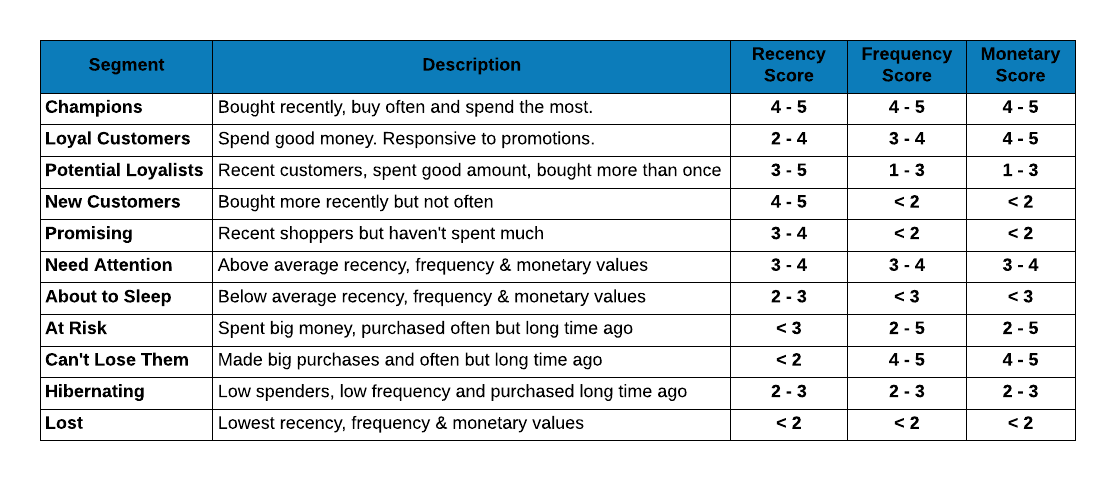
The following segments were chosen to be studied:
1. Champions
2. Loyal customers
3. New customers
4. Potential loyalists
5. Cannot lose them
6. At risk
7. Hibernating
8. Lost customers
9. Others

In [353]:
r, f, m = rfm["R_score"], rfm["F_score"], rfm["M_score"]

# slghtly modified conditions from the table
conditions = [
    (r >= 4) & (f >= 4) & (m >= 4), # Champions
    (r >= 2) & (f >= 3) & (m >= 4), # Loyal customers
    (r >= 4) & (f <= 2) & (m <= 2), # New customers
    (r >= 3) & (f <= 3) & (m <= 3), # Potential loyalists
    (r.between(3, 4)) & (f.between(3, 4)) & (m.between(3, 4)), # Need attention
    (r <= 2) & (f >= 4) & (m >= 4), # Cannot lose them
    (r <= 2) & (f >= 2) & (m >= 2), # At risk
    (r.between(2, 3)) & (f.between(2, 3)) & (m.between(2, 3)), # Hibernating
    (r >= 3) & (f >= 3) & (m <= 3), # Active customers
    (r <= 2) & (f <= 2) & (m <= 2) # Lost customers
]

# names of segments
choices = [
    "Champions", "Loyal customers", "New customers", "Potential loyalists",
    "Need attention", "Cannot lose them", "At risk", "Hibernating", "Active customers", "Lost customers"
]

# np.select is faster for this number of conditions compared to apply
# if client doesn't suit any group, they go to "Others"
rfm["Segment"] = np.select(conditions, choices, default="Others")

print("Total number of customers:", len(rfm["CustomerID"]))
rfm["Segment"].value_counts()

Total number of customers: 4334


Segment
Champions              956
Potential loyalists    731
Lost customers         671
At risk                633
Loyal customers        580
New customers          236
Others                 235
Need attention         139
Active customers       127
Cannot lose them        26
Name: count, dtype: int64

In [354]:
others = rfm[rfm["Segment"] == "Others"][["R_score", "F_score", "M_score"]]

# main statistics about segment
print("Number of customers in 'Others':", len(others))
others.describe()

Number of customers in 'Others': 235


,R_score,F_score,M_score
count,235.000000,235.000000,235.000000
mean,2.123404,1.731915,3.080851
std,1.123603,0.929366,1.293415
min,1.000000,1.000000,1.000000
25%,1.000000,1.000000,3.000000
50%,2.000000,1.000000,3.000000
75%,3.000000,2.000000,4.000000
max,5.000000,5.000000,5.000000


Others represent customers with relatively average behavioural characteristics with metrics which were not defined in earlier conditions. Their means of scores confirms that they are mid-range consumers. Therefore, their segment name will be changed to be more descriptive.

#### Customer segments pie chart

In [356]:
df_segments = rfm["Segment"].value_counts().reset_index(name="Count")

# creating pie chart
fig = px.pie(
    df_segments, 
    values="Count",
    names="Segment",
    color_discrete_sequence=px.colors.sequential.Blues[::-1],
    title="Customer segments"
)

# formating it
fig.update_layout(
    title_font=dict(size=18),
    title_x=0.5,
    width=800,
    height=600
)

fig.show()

#### Correlation matrix

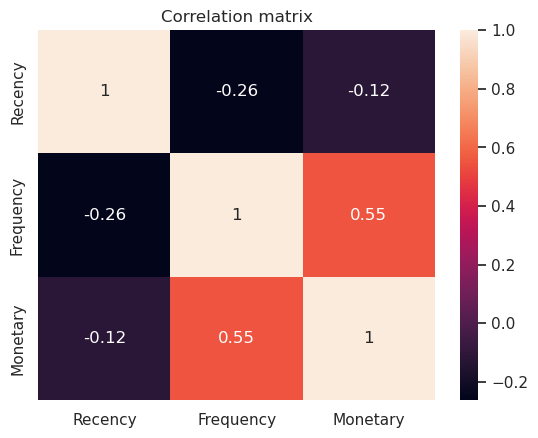

In [440]:
sns.heatmap(rfm[["Recency", "Frequency", "Monetary"]].corr(), annot=True)
plt.title("Correlation matrix")
plt.show()

#### Customer spending distribution

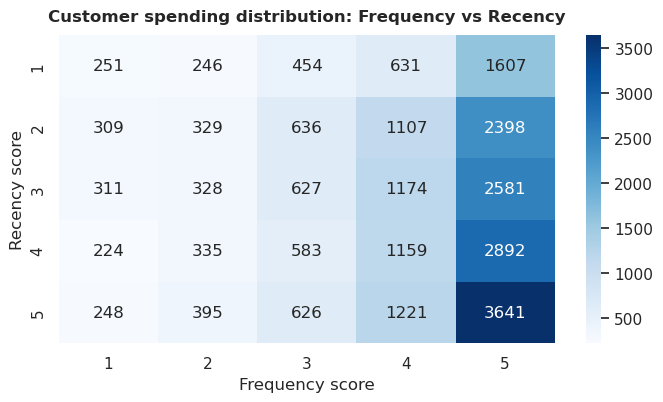

In [551]:
heatmap_data = rfm.pivot_table(
    values="Monetary", index="R_score", columns="F_score", aggfunc="median"
)

plt.figure(figsize=(8, 4))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="Blues")

plt.title("Customer spending distribution: Frequency vs Recency", weight="bold", pad=10)
plt.xlabel("Frequency score")
plt.ylabel("Recency score")
plt.show()

---
The correlation heatmap shows that the strongest positive correlation is between Frequency and Monetary (0.55), meaning that customers who buy more often also tend to spend more money in total. In other words, the most frequent buyers are the biggest spenders. Recency shows weak negative correlations with both Frequency (-0.26) and Monetary (-0.12), suggesting that as the time since the last purchase increases, the overall shopping frequency and total spending decrease.

The second heatmap illustrates customer spending distribution compared by Recency and Frequency scores on a scale of 1 to 5. It can be observed that median spending increases dramatically as Frequency score increases, confirming positive F–M correlation and that Frequency has stronger effect of Monetary value than Recency. This implies that purchasing frequency is a stronger predictor of customer value than recency alone.

In total, there were 4334 unique customers, separated into 10 different groups: 


| Segment | Description |
| :--- | :--- |
| **Champions (956)** | Highly valuable active customers |
| **Potential loyalists (731)** | Potential future champions |
| **Lost customers (671)** | Inactive low-value customers |
| **At risk (633)** | Previously active customers |
| **Loyal customers (580)** | Stable high-value customers |
| **New customers (236)** | Recently acquired customers |
| **Need attention (139)** | Average customers |
| **Active customers (127)** | Customers with moderate activity and lower monetary value |
| **Cannot lose them (26)** | High-value inactive customers |
| **Others (235)** | Moderate-value rarely active customers |



The largest segments were Champions and Potential loyalists (1687 together), while At Risk and Lost customer form nearly one-third of all customers, showing a serious vulnerability. Trying to recover lost customers would be too expensive with a low return on investment (ROI), focusing on retaining at-risk consumers would be more effective. Cannot Lose Them segment needs immediate intervention as they directly impact profitability (their orders are expensive despite only being 1.59% of all customers).

According to Khan (2013), customer loyalty is defined as "a deeply held commitment to re-buy or re-patronize a preferred product or service consistently in the future, thereby causing repetitive same-brand or same-brand set purchasing", which also results in recommendations to friends and associates. Thus, it is considered to be one of the most important factors for success in the future. Moreover, several other studies referenced by Khan suggest that obtaining a new customer may cost five or 6 times more than retaining an existing customer. Furthermore, even a small increase in customer retention can improve profitability (a 5% increase in customer retention can increase profits by 25% to 125%).

### Revenue share

In [359]:
segments_info = (
    rfm.groupby("Segment", as_index=False)
    .agg(
        Clients=("CustomerID", "nunique"),
        Revenue=("Monetary", "sum"),

        MedianRecency=("Recency", "median"),
        MedianFrequency=("Frequency", "median"),
        MedianMonetary=("Monetary", "median")
    )
)
# revenue share
segments_info["RevenueShare"] = segments_info["Revenue"] / rfm["Monetary"].sum()

# sorting in descending order
segments_info["Segment"] = pd.Categorical(segments_info["Segment"], categories=df_segments["Segment"].tolist(), ordered=True)
segments_info = segments_info.sort_values("Segment").reset_index(drop=True)

# customising order of columns
column_order = [
    "Segment", "Clients", "Revenue", "RevenueShare", 
    "MedianRecency", "MedianFrequency", "MedianMonetary"
]

segments_info = segments_info[column_order]
segments_info

,Segment,Clients,Revenue,RevenueShare,MedianRecency,MedianFrequency,MedianMonetary
0,Champions,956,5708059.490,0.653402,10.0,7.0,2615.560
1,Potential loyalists,731,314583.710,0.036010,40.0,2.0,401.400
2,Lost customers,671,133556.840,0.015288,239.0,1.0,177.340
3,At risk,633,437732.202,0.050107,174.0,2.0,517.530
4,Loyal customers,580,1500732.900,0.171789,59.0,4.0,1648.490
5,New customers,236,56360.430,0.006452,19.0,1.0,222.235
6,Others,235,314833.290,0.036039,128.0,1.0,781.030
7,Need attention,139,98141.711,0.011234,32.0,4.0,709.380
8,Active customers,127,74880.560,0.008572,12.0,4.0,609.300
9,Cannot lose them,26,97023.390,0.011106,212.0,5.0,1617.810


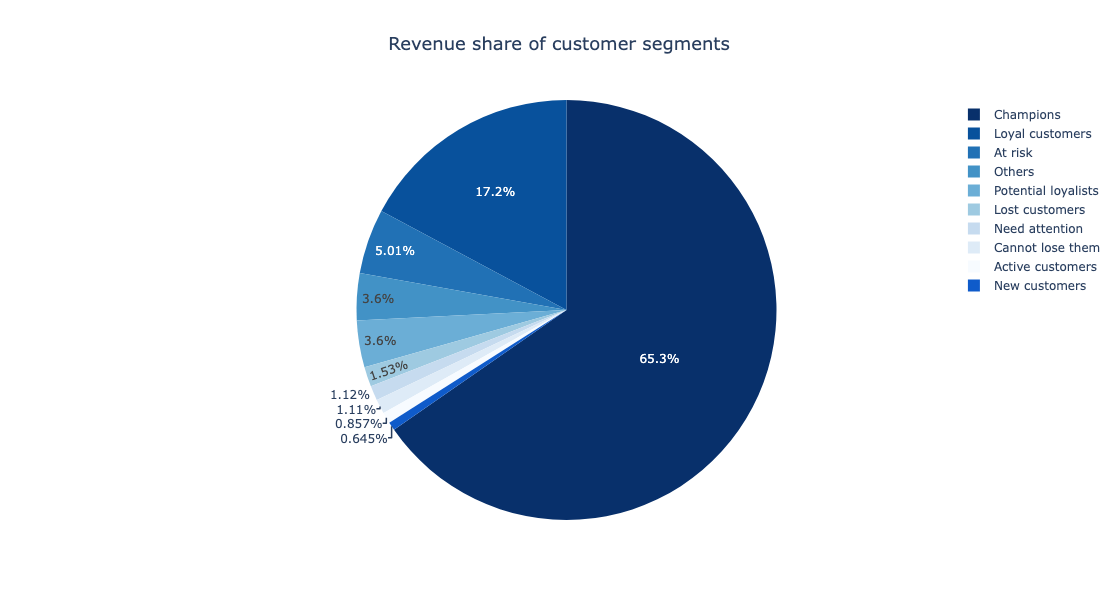

In [360]:
fig = px.pie(
    segments_info,
    values="Revenue",
    names="Segment",
    color_discrete_sequence=px.colors.sequential.Blues[::-1],
    title="Revenue share of customer segments"
)

fig.update_layout(
    title_font=dict(size=18),
    title_x=0.5,
    width=800,
    height=600
)

fig.show()

65.3% of revenue was generated by Champions (median £2615.56 with recency 10 days), confirming business was highly dependent on a single group, the reduction of which can cause serious financial instability. Together with Loyal customers (median £1648.49 with recency 59 days) they contribute over 80% of revenue and only 26.3% of clients, indicating that revenue is maintained by already existing customers rather than new ones. 

This is confirmed by the minimal financial impact of New Customers, who account for a mere 0.6% of revenue despite containing 236 people in it (5.45% of all customers). The company successfully acquired new users but it struggled to increase their average basket value (median £222.235). The frequency of at Risk is 2 compared to 1 for Lost. Thus, if the company manages to get a customer to buy a second time, their retention window is extended by an extra two months, giving the marketing team a much wider window to keep them active.

Moreover, At Risk segment (median £517.53 with recency 174 days) accounted for 5.01% of total revenue, which represented a substantial volume of lost active capital. This implies that the company should prioritise reducing their transition into Lost Customers as it is more cost-effective and can generate more revenue than trying to recover lost customers or getting new ones. As for Cannot lose them, they are also important despite generating only 1.11%, as they had big purchases with high frequency over 7 months ago, where possible reasons include negative customer service experience or switching to another competitor. Assigning 26 of such users to a dedicated customer support manager can help identify those problems and solve them to win them back.

## Results

Overall, there are 4,334 unique customers separated into 10 segments. 
Key conclusion include the following:
- Revenue is heavily concentrated since Champions (22% of customers) account for 65.3% of total revenue, while Champions and Loyal Customers together - 80%, meaning the business is highly dependent on retaining a relatively small group of existing customers and any significant changes wihtin these groups would have immediate financial consequences.
- New Customers represent 5.45% of all customers but only 0.6% of revenue, suggesting the business acquires customers effectively but struggles to increase their initial order value.
- At Risk customers represent recoverable revenue since they have demonstrated willingness to purchase repeatedly, as well as retaining them is more cost-effective than acquiring new customers.
- Customers who purchase more often also tend to spend more in total, meaning frequency is a reliable proxy for customer value in this dataset.

For each segment the following strategies ought to be considered:

| Segment | Description | Recommended strategy |
| :--- | :--- | :--- |
| **Champions (956)** | Highly valuable active customers | VIP loyalty programs, advocacy programs, early product access and personalised premium marketing campaigns to keep them satisfied and active. |
| **Potential loyalists (731)** | Potential future champions | Loyalty programs, targeted promotions, personalised product recommendations and onboarding into communities (social media, promotional emails and etc.) to shift them to the Champion sector. |
| **Lost customers (671)** | Inactive low-value customers | Automated retargeting (e.g. emails with discount offers or reminders), one-time aggressive deals (e.g. promocode for new purchase). If they do not respond, they should be removed from email marketing lists and CRM tracking software to save marketing costs. |
| **At risk (633)** | Previously active customers | High-value coupons for a limited amount of time, renewal reminders and feedback inquiries to re-engage them or understand why they might leave. |
| **Loyal customers (580)** | Stable high-value customers | Milestone rewards, cross-selling and referral programs for low-cost customer acquisition. |
| **New customers (236)** | Recently acquired customers | Welcome emails, introductory offers, social proof (e.g. customer-generated content and reviews) to form buying habits and trust in the seller. |
| **Need attention (139)** | Average customers | Personalised recommendations, limited-time offers and emails about accumulated loyalty points or unredeemed coupons to disrupt their normal purchasing patterns and prevent stalling. |
| **Active customers (127)** | Customers with moderate activity and lower monetary value | Cross-selling, bundle offers, regular promotional campaigns and A/B testing to increase their average order value. |
| **Cannot lose them (26)** | High-value inactive customers | Premium customer support, special vouchers for new purchases and personal inquiries to find out what changes would bring them back. |
| **Others (235)** | Moderate-value rarely active customers | General promotional campaings and cutomer guides to increase their activity and shift to other segments. |

In conclusion, the retailer should focus on targeted, high-ROI retention to protect its main customers, retain previously active and high-value users and optimize its onboarding funnel to fix the problem of encouraging larger orders from newer customers.

## References
1. Carrie. *E-commerce Data*. https://www.kaggle.com/datasets/carrie1/ecommerce-data
2. Moreno, A. I. (2025, September 23). *Is This Really a Jupyter Notebook? — Customizing Jupyter Notebook Appearance with CSS*. Medium; Data Science Collective. https://medium.com/data-science-collective/this-is-really-a-jupyter-notebook-customizing-jupyter-notebook-appearance-with-css-b04d71ccd0a8
3. Wei, J. T., Lin, S. Y., & Wu, H. H. (2010). *A review of the application of RFM model*. African journal of business management, 4(19), 4199.
4. Palmatier, R. W., Petersen, J. A., & Germann, F. (2022). Marketing analytics : Based on first principles. Bloomsbury Publishing Plc.
5. Safa. (2024, July 6). *Building an RFM Analytics Dashboard using Python*. Medium. https://medium.com/@safadataanalyst/building-an-rfm-analytics-dashboard-using-python-52159826f742
6. *pandas.Timedelta — pandas 2.0.1 documentation*. (n.d.). Pandas.pydata.org. https://pandas.pydata.org/docs/reference/api/pandas.Timedelta.html
7. *matplotlib.pyplot.subplots — Matplotlib 3.6.0 documentation*. (n.d.). Matplotlib.org. https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html
8. *pandas.DataFrame.agg — pandas 2.0.0 documentation*. (n.d.). Pandas.pydata.org. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.agg.html
9. *pandas.qcut — pandas 2.1.3 documentation*. (n.d.). Pandas.pydata.org. https://pandas.pydata.org/docs/reference/api/pandas.qcut.html
10. *numpy.log1p — NumPy v2.3.dev0 Manual*. (2025). Numpy.org. https://numpy.org/devdocs/reference/generated/numpy.log1p.html
11. *Customer Segmentation using RFM Analysis*. (n.d.). Blog.rsquaredacademy.com. https://blog.rsquaredacademy.com/customer-segmentation-using-rfm-analysis/
12. Yadav, A. (2025, February). *How numpy.select() Works?*. Medium. https://medium.com/@amit25173/how-numpy-select-works-f11ed0de629b
13. *Pie Charts*. (n.d.). Plotly.com. https://plotly.com/python/pie-charts/
14. *Layout*. (n.d.). Plotly.com. https://plotly.com/python/reference/layout/
15. Khan, M. T. (2013). *Customers loyalty: Concept & definition (a review)*. International Journal of Information, Business and Management, 5(3), 168-191.
16. Waskom, M. (2024). *seaborn.heatmap — seaborn 0.10.1 documentation*. Seaborn.pydata.org. https://seaborn.pydata.org/generated/seaborn.heatmap.html
17. *pandas.pivot_table — pandas 1.4.2 documentation*. (n.d.). Pandas.pydata.org. https://pandas.pydata.org/docs/reference/api/pandas.pivot_table.html

